# 04: Topology

*What are the structural properties of the graph?*

This notebook evaluates **topology** across all KGs listed in `config.yaml`, assessing whether
the graph structure reflects meaningful biological organisation and whether predictive signal
is well-distributed.

| Sub-metric | Definition | Quantification | Scoring |
|------------|-----------|----------------|--------|
| **Graph cohesion** | Fraction of nodes in the largest connected component (LCC) | LCC nodes / total nodes (0-1) | Direct: LCC fraction used as-is |
| **Clustering coefficient** | Mean local clustering C relative to a random graph | C (empirical) and C_ER (Erdos-Renyi expected); ratio C/C_ER | Log-scaled: min(1, log(C/C_ER) / log(100)) |
| **Known-pair recovery** | Whether validated therapeutic pairs are structurally preserved under edge dropout vs random pairs | Resilience Index (RI) for gold-standard and random pairs under 0-50% dropout | Differential Resilience Score: (RI_gold - RI_rand) / (1 - RI_rand) |
| **Community purity** | Alignment of Louvain communities with entity types | NMI (Louvain communities, entity type labels) | Direct: NMI in [0, 1] |

**Quantification focus.** The primary reported statistics are: LCC fraction, C, C_ER, C/C_ER
ratio, and Differential Resilience Score (DR) with RI_gold and RI_rand components.

**Scoring.** The dimension score is the equal-weighted mean of the four sub-metrics.
Known-pair recovery uses the DR score, which is density-invariant: a larger or denser KG
that preserves *all* pairs equally gains no advantage unless gold-standard pairs are
specifically resilient relative to random pairs.

**Inputs:** `config.yaml` - KG edge/node files (via `load_kg`)

**Outputs:** `results/figures/04_*.{pdf,png}` - `results/topology/*.csv` - `results/checkpoints/04_topology.pkl`

**Dependencies:** `src/loading.py` - `src/graph_utils.py` - `src/plotting.py`


## Set-up

In [1]:
# Imports
import sys, os, warnings, random, math, pickle
warnings.filterwarnings('ignore')
from pathlib import Path

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from collections import Counter, deque
from scipy import stats
import time
from tqdm.notebook import tqdm

from src.plotting import (setup_style, clean_ax, save_fig, bar_labels, panel_label,
                           TEXT_COLOR, TICK_COLOR, ALERT_RED, KG_PALETTE)
from src.loading import find_config, load_config, load_kg
from src.graph_utils import build_graph, build_lookup_maps

setup_style()
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics import silhouette_score, silhouette_samples

In [2]:
# Config & paths
config  = load_config(find_config(_root))
params  = config['analysis_params']
BASE    = config['_base_dir']
FIGS    = BASE / 'results' / 'figures';  FIGS.mkdir(parents=True, exist_ok=True)

# Shared plot helpers - thin spine used across bar panels
_SPINE = {'visible': True, 'color': '#333333', 'linewidth': 0.5}

def _style_left_spine(ax):
    for k, v in _SPINE.items():
        getattr(ax.spines['left'], f'set_{k}')(v)

def _style_bottom_spine(ax):
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)
    for k, v in _SPINE.items():
        getattr(ax.spines['bottom'], f'set_{k}')(v)

In [3]:
# Load KGs
kgs, graphs, maps = {}, {}, {}

for name in config['knowledge_graphs']:
    try:
        kg, nodes    = load_kg(name, config)
        G            = build_graph(kg, nodes)
        kgs[name]    = {'kg': kg, 'nodes': nodes}
        graphs[name] = G
        maps[name]   = build_lookup_maps(nodes)
        print(f'{name:12s}: {G.number_of_nodes():>8,} nodes  '
              f'{G.number_of_edges():>10,} edges  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND - skipped]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

KG_NAMES  = list(kgs.keys())
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}
LOADED    = [n for n in graphs if config['knowledge_graphs'].get(n, {}).get('relations')]
print(f'\nLoaded: {LOADED}')

primekg     :  129,375 nodes   4,049,642 edges    30 relation types
hetionet    :   47,031 nodes   2,107,709 edges    24 relation types
drkg        :   97,238 nodes   4,400,766 edges   107 relation types
openbilink  :  185,929 nodes   3,200,327 edges    28 relation types
biokg       :  105,524 nodes   2,043,846 edges    17 relation types

Loaded: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg']


## 1. Graph Cohesion

LCC size is the canonical structural integrity metric for complex networks. A well-curated KG should place >95% of nodes in a single largest connected component (LCC) — no single canonical threshold exists, but full LCC connectivity is used as an implicit curation quality signal in practice. Isolated nodes (degree 0) represent entities added to the node list but never linked by any edge.

In [4]:
# Connectivity analysis - LCC and component structure
def _connectivity_row(name: str, G: nx.Graph) -> dict:
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    lcc        = components[0]
    n          = G.number_of_nodes()

    if len(components) > 1:
        disc       = set().union(*components[1:])
        disc_types = Counter(G.nodes[v].get('node_type') for v in disc)
        top_disc   = ', '.join(f'{t} ({c:,})' for t, c in disc_types.most_common(3))
    else:
        top_disc = '-'

    return {
        'KG':                    name,
        'Nodes':                 n,
        'LCC nodes':             len(lcc),
        'LCC (%)':               round(100 * len(lcc) / n, 2),
        'Components':            len(components),
        'Isolated':              sum(1 for v in G if G.degree(v) == 0),
        'Top types outside LCC': top_disc,
    }

lcc_sets  = {name: sorted(nx.connected_components(graphs[name]),
                           key=len, reverse=True)[0]
             for name in LOADED}

conn_df = (pd.DataFrame([_connectivity_row(name, graphs[name]) for name in LOADED])
           .set_index('KG'))

with pd.option_context('display.max_colwidth', None):
    conn_df

  → Saved: 04_graph_cohesion.pdf / .png


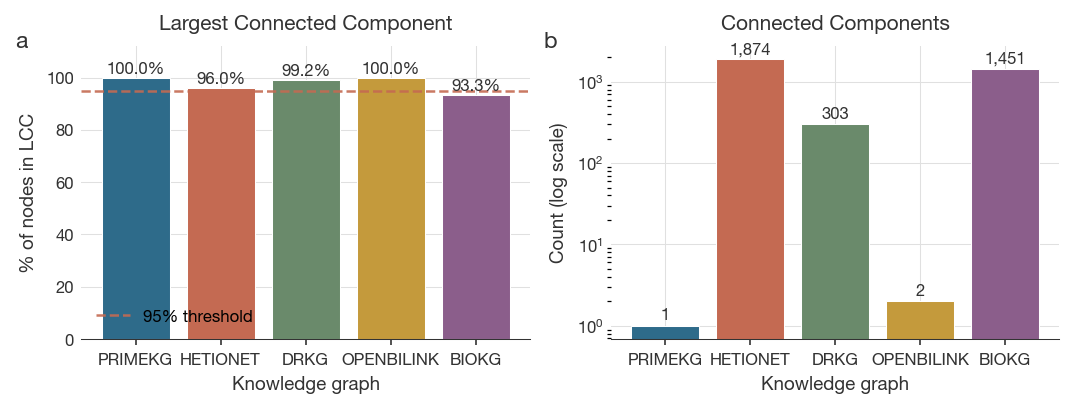

In [5]:
# Connectivity: LCC fraction and component count
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
names  = LOADED
colors = [KG_COLORS[n] for n in names]
labels = [n.upper() for n in names]

# Panel a - LCC fraction
ax       = axes[0]
lcc_vals = [conn_df.loc[n, 'LCC (%)'] for n in names]
bars     = ax.bar(names, lcc_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(95, color=ALERT_RED, ls='--', lw=1.2, alpha=0.9, label='95% threshold')
ax.set_ylim(0, 112)
ax.set_xticklabels(labels, fontsize=8)
ax.legend(fontsize=8, frameon=False)
_style_left_spine(ax)
bar_labels(ax, bars, fmt='{:.1f}%', offset=0.5, fontsize=8)
clean_ax(ax, title='Largest Connected Component',
         xlabel='Knowledge graph', ylabel='% of nodes in LCC')
panel_label(ax, 'a')

# Panel b - Component count
ax        = axes[1]
comp_vals = [conn_df.loc[n, 'Components'] for n in names]
bars      = ax.bar(names, comp_vals, color=colors, edgecolor='white', linewidth=0.5)
use_log   = any(v > 10 for v in comp_vals)
if use_log:
    ax.set_yscale('log')
ax.set_xticklabels(labels, fontsize=8)
_style_left_spine(ax)
for bar, val in zip(bars, comp_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * (1.18 if use_log else 1.03),
            f'{val:,}', ha='center', fontsize=8, color=TEXT_COLOR, fontweight='bold')
clean_ax(ax, title='Connected Components', xlabel='Knowledge graph',
         ylabel='Count' + (' (log scale)' if use_log else ''))
panel_label(ax, 'b')

plt.tight_layout()
save_fig(fig, FIGS, '04_graph_cohesion')
plt.show()

## 2. Clustering Coefficient

The **mean local clustering coefficient C** quantifies the tendency of nodes to form densely connected neighbourhoods — the degree to which a node's neighbours are also connected to each other.

We compare the empirical clustering coefficient against that of a degree-matched Erdős–Rényi random graph (C_ER ≈ ⟨k⟩/N) to obtain a normalised ratio C/C_ER. Values ≫ 1 confirm small-world structure with dense local neighbourhoods; values near 1 suggest random wiring.

In [6]:
# Clustering coefficient vs random graph expectation

CLUST_SAMPLE = params.get('clust_sample', 5_000)   # nodes sampled for large graphs

def _clustering_row(name: str, G: nx.Graph, seed: int) -> dict:
    n, m   = G.number_of_nodes(), G.number_of_edges()
    k_mean = 2 * m / n if n else 0
    c_er   = k_mean / n if n else 0

    sample = random.sample(list(G.nodes()), min(CLUST_SAMPLE, n))
# c_emp  = nx.average_clustering(G.subgraph(sample))
    c_emp = nx.average_clustering(G)
    ratio  = c_emp / c_er if c_er else float('inf')

    return {
        'KG':            name,
        'C (empirical)': round(c_emp, 4),
        'C_ER (random)': round(c_er, 6),
        'C / C_ER':      round(ratio, 1),
        'Small-world':   'OK' if ratio > 10 else ' X',
    }

seed = params.get('random_seed', 42)
random.seed(seed)

clust_df = pd.DataFrame([
    _clustering_row(name, graphs[name], seed) for name in LOADED
]).set_index('KG')

# Small-world score: log-scaled C/C_ER mapped to [0, 1]
# Formula: score = min(1, log(C/C_ER) / log(100))
#   - C/C_ER = 1   → score = 0.0  (no better than random)
#   - C/C_ER = 10  → score = 0.5  (moderate small-world)
#   - C/C_ER = 100 → score = 1.0  (strong small-world, saturates)
clust_df['SW score'] = clust_df['C / C_ER'].apply(
    lambda r: round(min(1.0, math.log(r) / math.log(100)), 3) if r > 1 else 0.0
)

print(clust_df.to_string())

            C (empirical)  C_ER (random)  C / C_ER Small-world  SW score
KG                                                                      
primekg            0.0761       0.000484     157.3          OK     1.000
hetionet           0.1086       0.001906      57.0          OK     0.878
drkg               0.2363       0.000931     253.8          OK     1.000
openbilink         0.1127       0.000185     608.7          OK     1.000
biokg              0.1371       0.000367     373.4          OK     1.000


  → Saved: 04_clustering_coefficient.pdf / .png


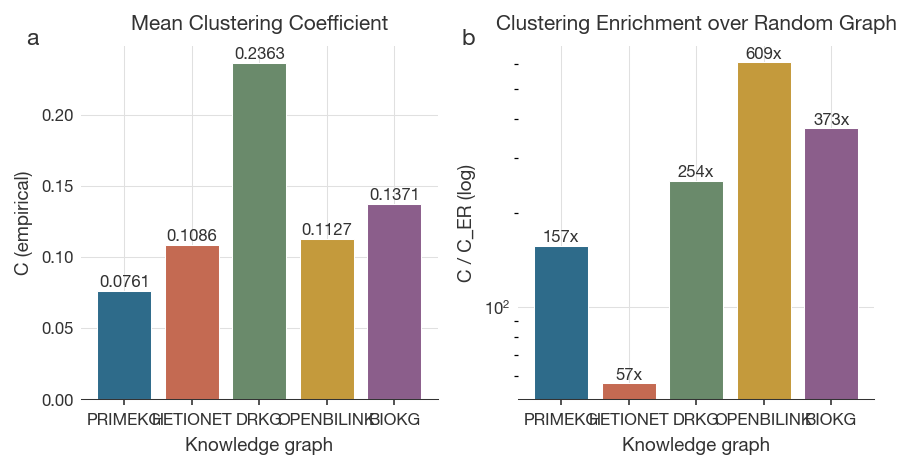

In [7]:
# Clustering coefficient - plot
fig, axes = plt.subplots(1, 2, figsize=(6.0, 3.2))
names  = LOADED
colors = [KG_COLORS[n] for n in names]
labels = [n.upper() for n in names]

panels = [
    ('a', 'Mean Clustering Coefficient',       'C (empirical)', 'C (empirical)',    '{:.4f}', False),
    ('b', 'Clustering Enrichment over Random Graph', 'C / C_ER', 'C / C_ER (log)',   '{:.0f}x', True),
]

for ax, (letter, title, col, ylabel, fmt, log) in zip(axes, panels):
    vals = [clust_df.loc[n, col] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.5)
    if log:
        ax.set_yscale('log')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.03,
                    fmt.format(val), ha='center', fontsize=8,
                    color=TEXT_COLOR, fontweight='bold')
    else:
        bar_labels(ax, bars, fmt=fmt, offset=0.001, fontsize=8)
    ax.set_xticklabels(labels, fontsize=8)
    _style_left_spine(ax)
    clean_ax(ax, title=title, xlabel='Knowledge graph', ylabel=ylabel)
    panel_label(ax, letter)

plt.tight_layout()
save_fig(fig, FIGS, '04_clustering_coefficient')
plt.show()

## 3. Known-Pair Recovery (External Gold Standard)

Using **Open Targets approved drug indications** (4,203 pairs) as an external gold standard,
we measure whether the KG's topology structurally encodes clinically validated therapeutic
relationships.

Two complementary analyses:

1. **Recovery curves** — what fraction of gold-standard pairs are reachable at 1–5 hops,
   compared with baseline KG size and density.

2. **Differential Resilience** — how well gold-standard pairs are *preserved* under
   progressive random edge dropout (0–50 %), relative to random pairs. This density-invariant
   score rewards structural specificity, not bulk connectivity.


In [8]:
# ── Load gold standard and build ID bridges ───────────────────────────
import re
from collections import defaultdict

GS_DIR = BASE / 'data' / 'gold_standards'
MAX_HOPS = 5

# Open Targets approved indications
gs = pd.read_csv(GS_DIR / 'opentargets_drug_indications.csv')
gs = gs[gs['is_approved'] == True].copy()
gs = gs.dropna(subset=['drugbank_id', 'mondo_id_mapped'])
gs['mondo_id_mapped'] = gs['mondo_id_mapped'].astype(int).astype(str)
print(f"Open Targets gold standard: {len(gs):,} approved pairs")

# MONDO ↔ DOID bridge (for Hetionet)
do_df = pd.read_csv(GS_DIR / 'do_diseases.csv')
do_df['mondo_num'] = do_df['mondo_id'].str.replace('MONDO:', '', regex=False).str.lstrip('0')
do_df['doid_num']  = do_df['doid'].str.replace('DOID:', '', regex=False)
mondo_to_doid = dict(zip(do_df['mondo_num'], do_df['doid_num']))

# MESH ↔ DOID bridge (for DRKG)
mesh_df = pd.read_csv(GS_DIR / 'mesh_to_doid.csv', on_bad_lines='skip')
mesh_df['mesh_clean'] = mesh_df['mesh_id'].str.split(' ').str[0].str.replace('MESH:', '', regex=False)
mesh_df['doid_num']   = mesh_df['doid'].str.replace('DOID:', '', regex=False)
doid_to_mesh = dict(zip(mesh_df['doid_num'], mesh_df['mesh_clean']))

# MONDO → MESH (via DOID)
mondo_to_mesh = {m: doid_to_mesh[d] for m, d in mondo_to_doid.items() if d in doid_to_mesh}

# Pre-build reverse lookups
doid_to_mondo = defaultdict(list)
for mondo, doid in mondo_to_doid.items():
    doid_to_mondo[doid].append(mondo)
mesh_to_mondo = defaultdict(list)
for mondo, mesh in mondo_to_mesh.items():
    mesh_to_mondo[mesh].append(mondo)

print(f"Bridges: MONDO→DOID {len(mondo_to_doid):,}, DOID→MESH {len(doid_to_mesh):,}, MONDO→MESH {len(mondo_to_mesh):,}")

Open Targets gold standard: 4,203 approved pairs
Bridges: MONDO→DOID 11,767, DOID→MESH 4,808, MONDO→MESH 4,752


In [9]:
# ── Map gold standard pairs to each KG's node indices ─────────────────

DRUG_TYPES    = {'drug', 'Compound', 'compound', 'Drug'}
DISEASE_TYPES = {'disease', 'Disease'}

def build_id_to_index(kg_name, nodes_df):
    """Map DrugBank drug IDs and MONDO disease IDs to KG node indices."""
    drug_map, disease_map = {}, {}
    disease_scheme = config['knowledge_graphs'][kg_name].get('disease_id_scheme', '')

    # OpenBioLink: drugs are PUBCHEM.COMPOUND:* IDs; DrugBank accession is
    # pre-mapped into nodes_df['drugbank_id'] by load_openbilink().
    _obl_pc_to_db = {}
    if kg_name == 'openbilink' and 'drugbank_id' in nodes_df.columns:
        mask = (nodes_df['type'] == 'Drug') & nodes_df['drugbank_id'].str.startswith('DB', na=False)
        _obl_pc_to_db = dict(zip(nodes_df.loc[mask, 'id'],
                                 nodes_df.loc[mask, 'drugbank_id']))

    for row in nodes_df.itertuples(index=False):
        node_id, node_type, node_idx = str(row.id), str(row.type), int(row.idx)

        if node_type.lower() in ('drug', 'compound'):
            if _obl_pc_to_db:
                # OpenBioLink: look up DrugBank ID from the pre-built mapping
                db_id = _obl_pc_to_db.get(node_id)
                if db_id:
                    drug_map[db_id] = node_idx
            else:
                match = re.search(r'(DB\d{5,})', node_id)
                if match:
                    drug_map[match.group(1)] = node_idx

        if node_type.lower() == 'disease':
            if disease_scheme == 'mondo':
                for part in node_id.split('_'):
                    part = part.strip().lstrip('0') or '0'
                    disease_map[part] = node_idx
            elif disease_scheme == 'doid':
                m = re.search(r'DOID:(\d+)', node_id)
                if m:
                    for mondo in doid_to_mondo.get(m.group(1), []):
                        disease_map[mondo] = node_idx
            elif disease_scheme == 'doid_mesh':
                m_mesh = re.search(r'MESH:(D\d+)', node_id)
                m_doid = re.search(r'DOID:(\d+)', node_id)
                if m_mesh:
                    for mondo in mesh_to_mondo.get(m_mesh.group(1), []):
                        disease_map[mondo] = node_idx
                if m_doid:
                    for mondo in doid_to_mondo.get(m_doid.group(1), []):
                        disease_map[mondo] = node_idx
            elif disease_scheme == 'mesh':
                # BioKG: bare MeSH IDs (D*, C*) — bridge via mesh_to_mondo
                m_bare = re.search(r'^([DC]\d+)', node_id)
                if m_bare:
                    for mondo in mesh_to_mondo.get(m_bare.group(1), []):
                        disease_map[mondo] = node_idx
    return drug_map, disease_map


def build_negative_pairs(name, pos_set, n_sample, rng):
    """Sample random drug-disease pairs not in the gold standard set."""
    G   = graphs[name]
    lcc = lcc_sets[name]
    drug_nodes    = [v for v in lcc if G.nodes[v].get('node_type') in DRUG_TYPES]
    disease_nodes = [v for v in lcc if G.nodes[v].get('node_type') in DISEASE_TYPES]
    if not drug_nodes or not disease_nodes:
        return []
    neg, attempts = [], 0
    while len(neg) < n_sample and attempts < n_sample * 20:
        d, dis = rng.choice(drug_nodes), rng.choice(disease_nodes)
        if (d, dis) not in pos_set and (dis, d) not in pos_set:
            neg.append((d, dis))
        attempts += 1
    return neg


# Map pairs
mapped_pairs = {}
for name in LOADED:
    drug_map, disease_map = build_id_to_index(name, kgs[name]['nodes'])
    lcc = lcc_sets[name]
    pairs = list(set(
        (drug_map[r['drugbank_id']], disease_map[str(r['mondo_id_mapped'])])
        for _, r in gs.iterrows()
        if r['drugbank_id'] in drug_map
        and str(r['mondo_id_mapped']) in disease_map
        and drug_map[r['drugbank_id']] in lcc
        and disease_map[str(r['mondo_id_mapped'])] in lcc
    ))
    mapped_pairs[name] = pairs
    print(f'{name:12s}: {len(drug_map):>5,} drugs  {len(disease_map):>5,} diseases  '
          f'{len(pairs):>5,} gold standard pairs mapped')

primekg     : 7,957 drugs  22,205 diseases  4,037 gold standard pairs mapped
hetionet    : 1,552 drugs    134 diseases    662 gold standard pairs mapped
drkg        : 10,563 drugs  2,087 diseases  2,861 gold standard pairs mapped
openbilink  : 5,358 drugs  9,285 diseases  3,174 gold standard pairs mapped
biokg       : 8,805 drugs  3,510 diseases  2,569 gold standard pairs mapped


In [10]:
# ── Recovery by hop distance (BFS shortest path) ─────────────────────
recovery_results = {}

for name in LOADED:
    G     = graphs[name]
    pairs = mapped_pairs[name]
    if not pairs:
        print(f"{name}: no mapped pairs, skipping")
        continue
    
    print(f"{name}: computing shortest paths for {len(pairs):,} pairs...")
    t0 = time.time()
    hop_distances = []
    for src, tgt in pairs:
        try:
            d = nx.shortest_path_length(G, src, tgt)
            hop_distances.append(d if d <= MAX_HOPS else None)
        except nx.NetworkXNoPath:
            hop_distances.append(None)
    
    total = len(pairs)
    recovery = {h: sum(1 for d in hop_distances if d is not None and d <= h) / total
                for h in range(1, MAX_HOPS + 1)}
    unreachable = sum(1 for d in hop_distances if d is None)
    
    recovery_results[name] = {
        'hop_distances': hop_distances,
        'recovery': recovery,
        'total_pairs': total,
        'unreachable': unreachable,
    }
    
    print(f"  {time.time()-t0:.1f}s  |  " +
          "  ".join(f"{h}-hop: {recovery[h]:.1%}" for h in range(1, MAX_HOPS+1)) +
          f"  |  unreachable: {unreachable:,} ({unreachable/total:.1%})")

primekg: computing shortest paths for 4,037 pairs...
  0.3s  |  1-hop: 37.3%  2-hop: 88.9%  3-hop: 99.4%  4-hop: 100.0%  5-hop: 100.0%  |  unreachable: 0 (0.0%)
hetionet: computing shortest paths for 662 pairs...
  0.0s  |  1-hop: 67.4%  2-hop: 91.7%  3-hop: 100.0%  4-hop: 100.0%  5-hop: 100.0%  |  unreachable: 0 (0.0%)
drkg: computing shortest paths for 2,861 pairs...
  0.3s  |  1-hop: 55.2%  2-hop: 94.5%  3-hop: 99.7%  4-hop: 100.0%  5-hop: 100.0%  |  unreachable: 0 (0.0%)
openbilink: computing shortest paths for 3,174 pairs...
  0.1s  |  1-hop: 32.5%  2-hop: 60.1%  3-hop: 91.1%  4-hop: 98.8%  5-hop: 99.8%  |  unreachable: 7 (0.2%)
biokg: computing shortest paths for 2,569 pairs...
  0.2s  |  1-hop: 43.7%  2-hop: 92.5%  3-hop: 99.4%  4-hop: 100.0%  5-hop: 100.0%  |  unreachable: 0 (0.0%)


### Differential resilience: gold standard vs random


In [11]:
# -- Path counting functions + dropout-resilience infrastructure ------

def count_paths_by_hop(adj, src, tgt, max_hops=3):
    """Count simple paths at each hop distance (1 through max_hops)."""
    counts = {h: 0 for h in range(1, max_hops + 1)}
    if tgt in adj.get(src, set()):
        counts[1] = 1
    for a in adj.get(src, set()):
        if a == tgt: continue
        if tgt in adj.get(a, set()):
            counts[2] += 1
    if max_hops >= 3:
        for a in adj.get(src, set()):
            if a == tgt: continue
            for b in adj.get(a, set()):
                if b in (src, a, tgt): continue
                if tgt in adj.get(b, set()):
                    counts[3] += 1
    return counts


# -- Indexed adjacency + fast dropout BFS ----------------------------

def build_indexed_adj(G):
    """Compact edge array + index mappings for fast dropout sampling.

    Returns: node_list, edges (np.ndarray E x 2 int32),
             node_to_idx (dict), adj_idx (dict idx -> set of neighbour idxs).
    """
    node_list   = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    edges = np.array(
        [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()],
        dtype=np.int32
    )
    adj_idx = {}
    for u_i, v_i in edges:
        adj_idx.setdefault(int(u_i), set()).add(int(v_i))
        adj_idx.setdefault(int(v_i), set()).add(int(u_i))
    return node_list, edges, node_to_idx, adj_idx


def _bfs_reachable(adj, src, tgt, max_hops=2):
    """BFS reachability on index-keyed adjacency dict."""
    if src == tgt:
        return True
    visited = {src}
    queue   = [(src, 0)]
    qi      = 0
    while qi < len(queue):
        node, d = queue[qi]; qi += 1
        if d >= max_hops:
            continue
        for nbr in adj.get(node, ()):
            if nbr == tgt:
                return True
            if nbr not in visited:
                visited.add(nbr)
                queue.append((nbr, d + 1))
    return False


def recovery_under_dropout(edges, idx_pairs, drop_rate, rng,
                            max_hops=2, n_trials=3):
    """Mean 2-hop recovery fraction after randomly removing drop_rate of edges."""
    if not idx_pairs:
        return 0.0
    n_edges  = len(edges)
    n_remove = int(round(drop_rate * n_edges))
    trials   = []
    for _ in range(n_trials):
        if n_remove > 0:
            drop_mask = np.zeros(n_edges, dtype=bool)
            drop_mask[rng.choice(n_edges, size=n_remove, replace=False)] = True
            kept = edges[~drop_mask]
        else:
            kept = edges
        adj_d = {}
        for u, v in kept:
            adj_d.setdefault(int(u), set()).add(int(v))
            adj_d.setdefault(int(v), set()).add(int(u))
        hits = sum(1 for si, ti in idx_pairs
                   if _bfs_reachable(adj_d, si, ti, max_hops))
        trials.append(hits / len(idx_pairs))
    return float(np.mean(trials))


def resilience_index(drop_rates, recoveries):
    """Normalised AUC (trapezoid) of recovery-vs-dropout curve -> [0, 1]."""
    dr = np.array(drop_rates, dtype=float)
    rc = np.array(recoveries, dtype=float)
    auc     = float(np.trapezoid(rc, dr))
    max_auc = float(dr[-1] - dr[0])
    return round(auc / max_auc, 4) if max_auc > 0 else 0.0


In [12]:
# -- Differential Resilience: gold standard vs random dropout curves --
#
# Replaces the CLES / Mann-Whitney 2-hop path-count analysis.
#
# For each KG:
#   1. Sample N_SAMPLE gold-standard and random pairs
#   2. At each DROP_RATE measure mean 2-hop recovery (N_TRIALS trials)
#   3. Compute RI (normalised AUC) for both groups
#   4. DR score = (RI_gold - RI_rand) / max(eps, 1 - RI_rand)
#
# DR score: fraction of headroom above random filled by validated edges.

import sys, time, numpy as np
rng_dr     = np.random.RandomState(params.get('random_seed', 42))
N_SAMPLE   = 300
DROP_RATES = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
DR_MAX_HOPS = 2   # separate from global MAX_HOPS (used for recovery curves)
N_TRIALS   = 3
MAX_HOPS = 5

diversity_results = {}

for name in LOADED:
    if name not in recovery_results:
        continue

    G       = graphs[name]
    pairs   = mapped_pairs[name]
    pos_set = set(pairs)

    print(f'\n{name}: building indexed adjacency...')
    t0 = time.time()
    node_list, edges, node_to_idx, adj_idx = build_indexed_adj(G)

    # Sample and convert to index space
    n_pos       = min(N_SAMPLE, len(pairs))
    sampled_pos = [pairs[i] for i in rng_dr.choice(len(pairs), size=n_pos, replace=False)]
    sampled_neg = build_negative_pairs(name, pos_set, n_pos, rng_dr)

    gold_idx = [(node_to_idx[s], node_to_idx[t])
                for s, t in sampled_pos
                if s in node_to_idx and t in node_to_idx]
    rand_idx = [(node_to_idx[s], node_to_idx[t])
                for s, t in sampled_neg
                if s in node_to_idx and t in node_to_idx]

    print(f'  gold={len(gold_idx)}  random={len(rand_idx)}  '
          f'edges={len(edges):,}  [{time.time()-t0:.1f}s]')

    # Compute dropout curves
    gold_curve, rand_curve = [], []
    for rate in DROP_RATES:
        t1  = time.time()
        r_g = recovery_under_dropout(edges, gold_idx, rate, rng_dr, DR_MAX_HOPS, N_TRIALS)
        r_r = recovery_under_dropout(edges, rand_idx, rate, rng_dr, DR_MAX_HOPS, N_TRIALS)
        gold_curve.append(r_g)
        rand_curve.append(r_r)
        print(f'\r  rate={rate:.2f}  gold={r_g:.3f}  random={r_r:.3f}  '
              f'[{time.time()-t1:.1f}s]', end='')
        sys.stdout.flush()
    print()

    # Resilience index + differential score
    ri_gold  = resilience_index(DROP_RATES, gold_curve)
    ri_rand  = resilience_index(DROP_RATES, rand_curve)
    headroom = max(1e-6, 1.0 - ri_rand)
    dr_score = round((ri_gold - ri_rand) / headroom, 4)

    diversity_results[name] = {
        'drop_rates': DROP_RATES,
        'gold_curve': gold_curve,
        'rand_curve': rand_curve,
        'ri_gold':    ri_gold,
        'ri_rand':    ri_rand,
        'dr_score':   dr_score,
        'n_gold':     len(gold_idx),
        'n_rand':     len(rand_idx),
    }

    print(f'  RI_gold={ri_gold:.4f}  RI_rand={ri_rand:.4f}  DR_score={dr_score:.4f}')

    del edges, adj_idx, node_to_idx, node_list



primekg: building indexed adjacency...
  gold=300  random=300  edges=4,049,642  [4.7s]
  rate=0.50  gold=0.761  random=0.027  [16.8s]
  RI_gold=0.8284  RI_rand=0.0349  DR_score=0.8222

hetionet: building indexed adjacency...
  gold=300  random=300  edges=2,107,709  [1.9s]
  rate=0.50  gold=0.724  random=0.112  [5.6s]]
  RI_gold=0.8531  RI_rand=0.1930  DR_score=0.8180

drkg: building indexed adjacency...
  gold=300  random=300  edges=4,400,766  [5.0s]
  rate=0.50  gold=0.863  random=0.028  [13.5s]
  RI_gold=0.9208  RI_rand=0.0547  DR_score=0.9162

openbilink: building indexed adjacency...
  gold=300  random=300  edges=3,200,327  [4.0s]
  rate=0.50  gold=0.381  random=0.001  [9.3s]]
  RI_gold=0.5106  RI_rand=0.0020  DR_score=0.5096

biokg: building indexed adjacency...
  gold=300  random=300  edges=2,043,846  [2.0s]
  rate=0.50  gold=0.852  random=0.069  [10.7s]
  RI_gold=0.9001  RI_rand=0.0937  DR_score=0.8898


### Recovery curves & differential resilience plots


  → Saved: 04c_known_pair_recovery.pdf / .png


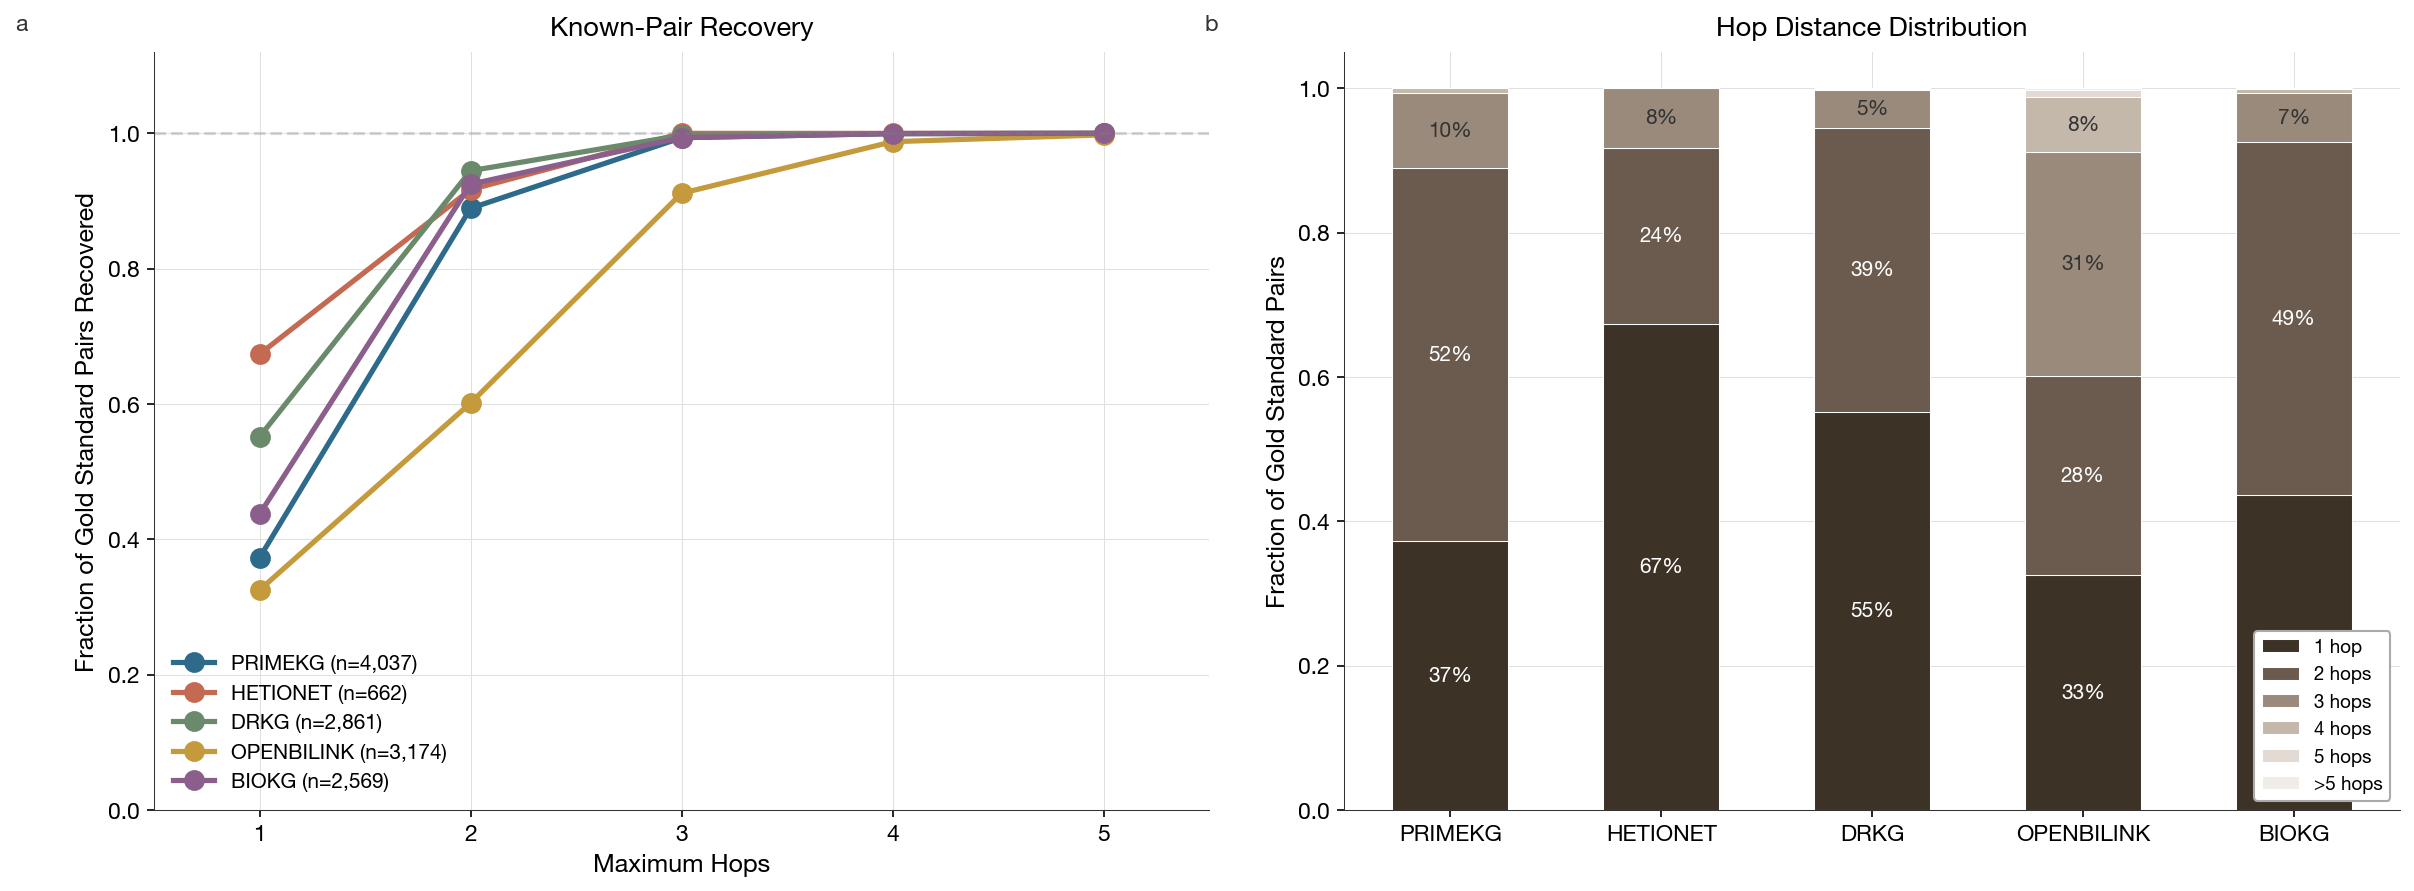

In [13]:
# ── Figure: Recovery curves + hop distance distribution ────────────────

HOP_COLORS = ['#3d3226', '#6b5b4e', '#9a8a7b', '#c4b8ab', '#e3dbd3', '#f0ece8']
HOP_LABELS = ['1 hop', '2 hops', '3 hops', '4 hops', '5 hops', f'>{MAX_HOPS} hops']

avail = [n for n in LOADED if n in recovery_results]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel a: Recovery curves
ax = axes[0]
hops = list(range(1, MAX_HOPS + 1))
for name in avail:
    r = recovery_results[name]['recovery']
    vals = [r[h] for h in hops]
    ax.plot(hops, vals, 'o-', color=KG_COLORS[name],
            label=f"{name.upper()} (n={recovery_results[name]['total_pairs']:,})",
            linewidth=2.5, markersize=9)

# Label placement — enforce minimum separation to avoid crowding
label_points = []
for name in avail:
    r = recovery_results[name]['recovery']
    for h in hops:
        label_points.append((h, r[h], name))

hop_groups = {}
for h, v, name in label_points:
    hop_groups.setdefault(h, []).append((v, name))

MIN_SEP = 0.04   # minimum y-axis separation before we stagger labels

for h, entries in hop_groups.items():
    entries.sort(key=lambda x: x[0], reverse=True)   # highest first

    # Assign y-offsets: push labels apart if they would overlap
    assigned = []          # (v, name, y_offset_points, x_offset_points)
    last_label_v = None
    x_cycle = [0, -26, 26, -26]   # alternate left/right for crowded points

    for idx, (v, name) in enumerate(entries):
        if last_label_v is not None and abs(v - last_label_v) < MIN_SEP:
            # Too close — use alternating x-offset instead of stacking vertically
            xoff = x_cycle[idx % len(x_cycle)]
            yoff = 10
        else:
            xoff = 0
            yoff = 12
        assigned.append((v, name, yoff, xoff))
        last_label_v = v


ax.set_xlabel('Maximum Hops', fontsize=12)
ax.set_ylabel('Fraction of Gold Standard Pairs Recovered', fontsize=12)
ax.set_title('Known-Pair Recovery', fontsize=13, fontweight='bold')
ax.set_xticks(hops)
ax.tick_params(axis='both', labelsize=11)
ax.set_xlim(0.5, MAX_HOPS + 0.5)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10, framealpha=1.0, facecolor='white', edgecolor='#ccc')
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.3)
panel_label(ax, 'a')

# Panel b: Hop distance distribution (stacked bar)
ax = axes[1]
x = np.arange(len(avail))
width = 0.55
for name_idx, name in enumerate(avail):
    dists = recovery_results[name]['hop_distances']
    total = len(dists)
    fracs = [sum(1 for d in dists if d == h) / total for h in range(1, MAX_HOPS + 1)]
    fracs.append(sum(1 for d in dists if d is None) / total)
    bottom = 0
    labels_list = HOP_LABELS if name_idx == 0 else [None] * len(HOP_LABELS)
    for frac, color, label in zip(fracs, HOP_COLORS, labels_list):
        ax.bar(name_idx, frac, width, bottom=bottom, color=color, label=label,
               edgecolor='white', linewidth=0.5)
        if frac > 0.04:
            ax.text(name_idx, bottom + frac/2, f'{frac:.0%}',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if color in ('#3d3226', '#6b5b4e') else '#333')
        bottom += frac
ax.set_xticks(x)
ax.set_xticklabels([n.upper() for n in avail], fontsize=11)
ax.set_ylabel('Fraction of Gold Standard Pairs', fontsize=12)
ax.set_title('Hop Distance Distribution', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)
leg = ax.legend(loc='lower right', fontsize=9, framealpha=1.0,
                facecolor='white', edgecolor='#aaa', frameon=True)
leg.get_frame().set_linewidth(1.0)
ax.set_ylim(0, 1.05)
panel_label(ax, 'b')

plt.tight_layout()
save_fig(fig, FIGS, '04c_known_pair_recovery')
plt.show()


  → Saved: 04c_known_pair_recovery.pdf / .png


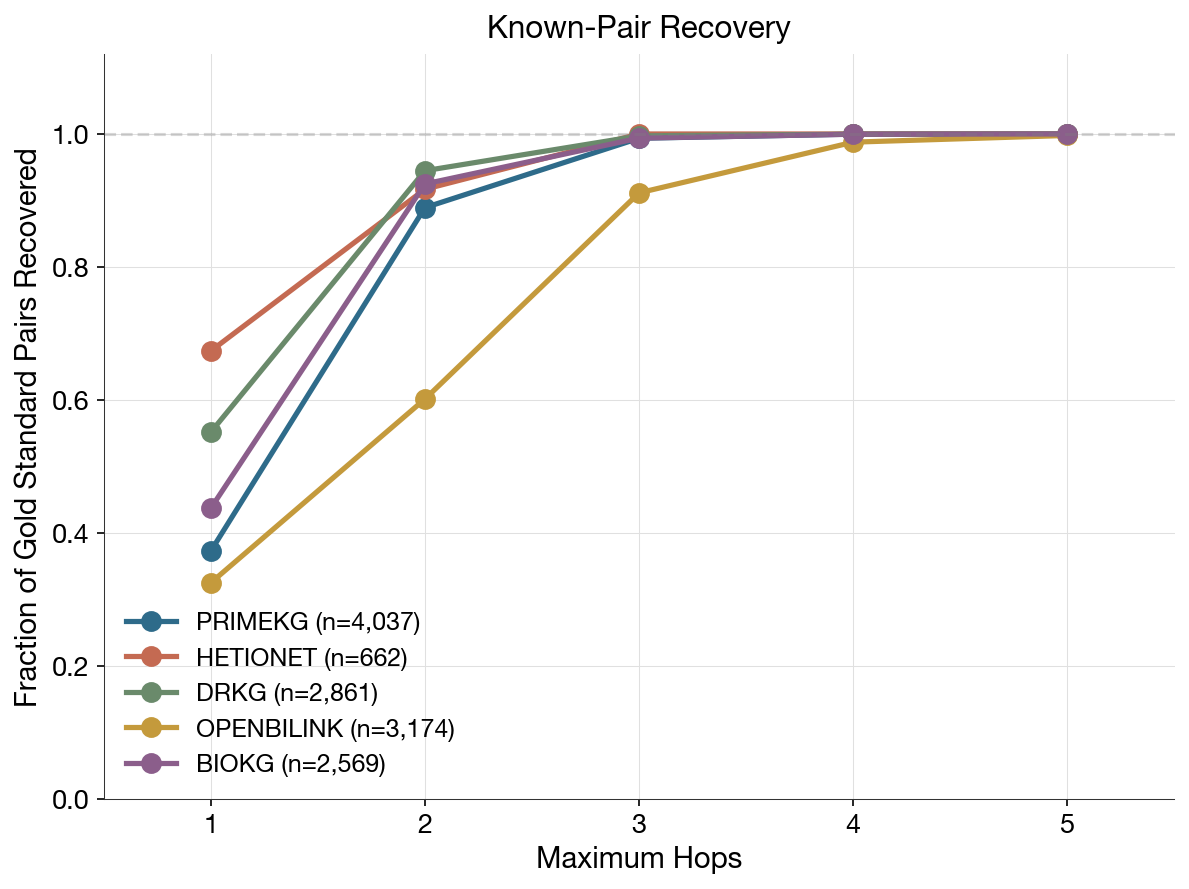

In [20]:
avail = [n for n in LOADED if n in recovery_results]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

hops = list(range(1, MAX_HOPS + 1))
for name in avail:
    r = recovery_results[name]['recovery']
    vals = [r[h] for h in hops]
    ax.plot(hops, vals, 'o-', color=KG_COLORS[name],
            label=f"{name.upper()} (n={recovery_results[name]['total_pairs']:,})",
            linewidth=2.5, markersize=9)

ax.set_xlabel('Maximum Hops', fontsize=14)
ax.set_ylabel('Fraction of Gold Standard Pairs Recovered', fontsize=14)
ax.set_title('Known-Pair Recovery', fontsize=15, fontweight='bold')
ax.set_xticks(hops)
ax.tick_params(axis='both', labelsize=13)
ax.set_xlim(0.5, MAX_HOPS + 0.5)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12, framealpha=1.0, facecolor='white', edgecolor='#ccc')
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.3)

plt.tight_layout()
save_fig(fig, FIGS, '04c_known_pair_recovery')
plt.show()

  → Saved: 04d_differential_resilience.pdf / .png


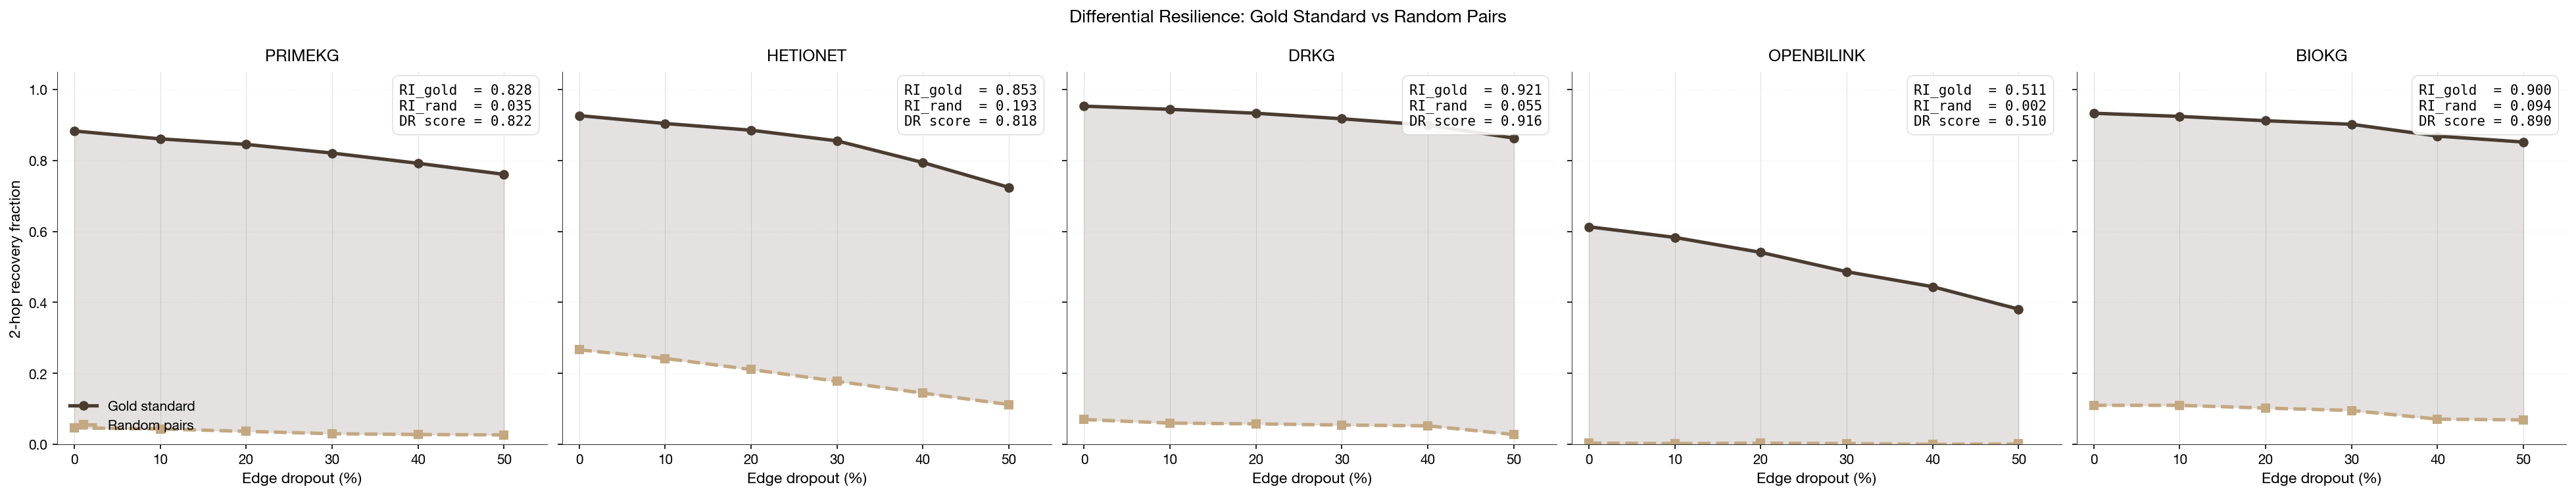

In [14]:
# -- Figure: Differential resilience dropout curves -------------------

GS_COLOR  = '#4a3c31'
RND_COLOR = '#c4a882'

avail_div = [n for n in LOADED if n in diversity_results]
n_kgs     = len(avail_div)

fig_dr, axes = plt.subplots(1, n_kgs, figsize=(5.2 * n_kgs, 4.5),
                             sharey=True, constrained_layout=True)
if n_kgs == 1:
    axes = [axes]

for ax, name in zip(axes, avail_div):
    res            = diversity_results[name]
    rates_pct      = [r * 100 for r in res['drop_rates']]
    gold_c, rand_c = res['gold_curve'], res['rand_curve']
    ri_g, ri_r     = res['ri_gold'], res['ri_rand']
    dr_s           = res['dr_score']

    ax.plot(rates_pct, gold_c, '-o', color=GS_COLOR, linewidth=2.5,
            markersize=6, label='Gold standard')
    ax.plot(rates_pct, rand_c, '--s', color=RND_COLOR, linewidth=2.5,
            markersize=6, label='Random pairs')
    ax.fill_between(rates_pct, rand_c, gold_c,
                    where=[g >= r for g, r in zip(gold_c, rand_c)],
                    alpha=0.15, color=GS_COLOR)

    info = (f'RI_gold  = {ri_g:.3f}\n'
            f'RI_rand  = {ri_r:.3f}\n'
            f'DR score = {dr_s:.3f}')
    ax.text(0.97, 0.97, info, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#ccc', alpha=0.9))

    ax.set_xlabel('Edge dropout (%)', fontsize=11)
    ax.set_title(name.upper(), fontsize=12, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(-2, 55)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel(f'{DR_MAX_HOPS}-hop recovery fraction', fontsize=11)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=GS_COLOR, linewidth=2.5, marker='o', markersize=6,
           label='Gold standard'),
    Line2D([0], [0], color=RND_COLOR, linewidth=2.5, linestyle='--',
           marker='s', markersize=6, label='Random pairs'),
]
axes[0].legend(handles=handles, fontsize=10, framealpha=1.0,
               facecolor='white', edgecolor='#ccc', loc='lower left')

fig_dr.suptitle('Differential Resilience: Gold Standard vs Random Pairs',
                fontsize=13, fontweight='bold', y=1.08)

save_fig(fig_dr, FIGS, '04d_differential_resilience')
plt.show()


## 4. Community Purity


In [15]:
# Community purity - Louvain community detection + NMI against entity types
RESOLUTION = 1.0

community_results = {}

for name, G in graphs.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()}")
    print(f"{'='*60}")

    # Louvain community detection
    t0 = time.time()
    communities = nx.community.louvain_communities(G, resolution=RESOLUTION, seed=42)
    print(f"  Found {len(communities)} communities ({time.time()-t0:.1f}s)")

    # Build node -> community mapping
    node_to_community = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = i

    # Compare communities vs entity types (full graph)
    all_nodes = list(G.nodes())
    entity_labels = [G.nodes[n].get('node_type', 'unknown') for n in all_nodes]
    community_labels = [node_to_community.get(n, -1) for n in all_nodes]

    nmi = normalized_mutual_info_score(entity_labels, community_labels)
    ari = adjusted_rand_score(entity_labels, community_labels)

    community_results[name] = {
        'communities': communities,
        'node_to_community': node_to_community,
        'n_communities': len(communities),
        'nmi': nmi,
        'ari': ari,
    }
    print(f"  NMI (communities vs entity types): {nmi:.4f}")
    print(f"  ARI (communities vs entity types): {ari:.4f}")



  PRIMEKG
  Found 576 communities (25.0s)
  NMI (communities vs entity types): 0.5480
  ARI (communities vs entity types): 0.4486

  HETIONET
  Found 1881 communities (20.6s)
  NMI (communities vs entity types): 0.2903
  ARI (communities vs entity types): 0.2097

  DRKG
  Found 464 communities (36.8s)
  NMI (communities vs entity types): 0.1971
  ARI (communities vs entity types): 0.1043

  OPENBILINK
  Found 233 communities (31.4s)
  NMI (communities vs entity types): 0.3408
  ARI (communities vs entity types): 0.1992

  BIOKG
  Found 1529 communities (20.3s)
  NMI (communities vs entity types): 0.1750
  ARI (communities vs entity types): 0.0704


In [16]:
# Community composition - inspect top communities per KG
for name, G in graphs.items():
    node_to_community = community_results[name]['node_to_community']

    print(f"\n{'='*60}")
    print(f"  {name.upper()} — Top 10 communities by size")
    print(f"{'='*60}")

    comm_types = {}
    for node in G.nodes():
        c = node_to_community.get(node, -1)
        t = G.nodes[node].get('node_type', 'unknown')
        comm_types.setdefault(c, Counter())[t] += 1

    sorted_comms = sorted(comm_types.items(), key=lambda x: sum(x[1].values()), reverse=True)
    for c, type_counts in sorted_comms[:10]:
        total = sum(type_counts.values())
        dominant = type_counts.most_common(1)[0]
        purity = dominant[1] / total
        print(f"  Community {c:>3d}: {total:>6,} nodes, "
              f"dominant={dominant[0]} ({purity:.0%}), "
              f"types={dict(type_counts)}")



  PRIMEKG — Top 10 communities by size
  Community 248: 37,301 nodes, dominant=gene/protein (67%), types={'gene/protein': 24969, 'drug': 2295, 'disease': 358, 'biological_process': 4450, 'molecular_function': 1716, 'cellular_component': 1635, 'exposure': 18, 'pathway': 1391, 'anatomy': 466, 'effect/phenotype': 3}
  Community  34: 35,597 nodes, dominant=biological_process (64%), types={'gene/protein': 2478, 'drug': 1155, 'effect/phenotype': 97, 'disease': 3953, 'biological_process': 22698, 'molecular_function': 3232, 'cellular_component': 389, 'exposure': 758, 'pathway': 831, 'anatomy': 6}
  Community 414: 26,122 nodes, dominant=effect/phenotype (55%), types={'gene/protein': 136, 'drug': 85, 'effect/phenotype': 14287, 'disease': 11568, 'biological_process': 7, 'exposure': 37, 'pathway': 1, 'cellular_component': 1}
  Community   1:  5,745 nodes, dominant=drug (72%), types={'gene/protein': 65, 'drug': 4117, 'effect/phenotype': 421, 'disease': 1112, 'biological_process': 8, 'molecular_fun

In [17]:
# Silhouette analysis (sampled) - structural separation of entity types
SAMPLE_SIZE = 20000

def shared_neighbour_distance_matrix(G, sample_nodes):
    """Pairwise distance = 1 - Jaccard(N(u), N(v))."""
    n = len(sample_nodes)
    nbr_sets = {node: set(G.neighbors(node)) for node in sample_nodes}
    dist = np.ones((n, n), dtype=np.float32)
    np.fill_diagonal(dist, 0.0)
    for i in range(n):
        ni = nbr_sets[sample_nodes[i]]
        if not ni:
            continue
        for j in range(i + 1, n):
            nj = nbr_sets[sample_nodes[j]]
            if not nj:
                continue
            intersection = len(ni & nj)
            if intersection > 0:
                union = len(ni | nj)
                d = 1.0 - (intersection / union)
                dist[i, j] = d
                dist[j, i] = d
    return dist

def stratified_sample(G, n_total, seed=42):
    """Sample nodes stratified by entity type, maintaining proportions."""
    rng = np.random.RandomState(seed)
    type_nodes = {}
    for node, data in G.nodes(data=True):
        t = data.get('node_type', 'unknown')
        type_nodes.setdefault(t, []).append(node)
    n_total = min(n_total, G.number_of_nodes())
    sampled = []
    for t, nodes in type_nodes.items():
        n_type = max(1, int(n_total * len(nodes) / G.number_of_nodes()))
        n_type = min(n_type, len(nodes))
        sampled.extend(rng.choice(nodes, size=n_type, replace=False).tolist())
    return sampled[:n_total]

silhouette_results = {}

for name, G in graphs.items():
    node_to_community = community_results[name]['node_to_community']

    print(f"\n{'='*60}")
    print(f"  {name.upper()}")
    print(f"{'='*60}")

    sample_nodes = stratified_sample(G, SAMPLE_SIZE, seed=42)
    print(f"  Sampling {len(sample_nodes)} nodes...")

    t0 = time.time()
    dist_matrix = shared_neighbour_distance_matrix(G, sample_nodes)
    print(f"  Distance matrix computed ({time.time()-t0:.1f}s)")

    sample_entity_labels = [G.nodes[n].get('node_type', 'unknown') for n in sample_nodes]
    sample_community_labels = [node_to_community.get(n, -1) for n in sample_nodes]

    result = {}

    if len(set(sample_entity_labels)) >= 2:
        sil_entity = silhouette_score(dist_matrix, sample_entity_labels, metric='precomputed')
        sil_samples = silhouette_samples(dist_matrix, sample_entity_labels, metric='precomputed')
        result['silhouette_entity_type'] = sil_entity
        print(f"  Silhouette (entity types): {sil_entity:.4f}")

        for t in sorted(set(sample_entity_labels)):
            mask = [l == t for l in sample_entity_labels]
            print(f"    {t:20s}: {float(np.mean(sil_samples[mask])):.4f}")

    if len(set(sample_community_labels)) >= 2:
        sil_louvain = silhouette_score(dist_matrix, sample_community_labels, metric='precomputed')
        result['silhouette_louvain'] = sil_louvain
        print(f"  Silhouette (Louvain communities): {sil_louvain:.4f}")

    silhouette_results[name] = result

    community_results[name].update(result)



  PRIMEKG
  Sampling 19994 nodes...
  Distance matrix computed (119.4s)
  Silhouette (entity types): 0.0318
    anatomy             : 0.0031
    biological_process  : -0.0000
    cellular_component  : 0.0090
    disease             : 0.0031
    drug                : 0.0305
    effect/phenotype    : -0.0001
    exposure            : 0.0118
    gene/protein        : 0.1334
    molecular_function  : 0.0032
    pathway             : 0.0023
  Silhouette (Louvain communities): 0.0294

  HETIONET
  Sampling 19993 nodes...
  Distance matrix computed (340.3s)
  Silhouette (entity types): 0.0314
    Anatomy             : 0.0096
    Biological Process  : -0.0006
    Cellular Component  : 0.0000
    Compound            : 0.0416
    Disease             : 0.0120
    Gene                : 0.0651
    Molecular Function  : -0.0007
    Pathway             : 0.0031
    Pharmacologic Class : 0.0004
    Side Effect         : 0.0071
    Symptom             : 0.0149
  Silhouette (Louvain communities): 0.009

        KG  Communities      NMI      ARI  Silhouette (entity)  Silhouette (Louvain)
   primekg          576 0.548036 0.448642             0.031837              0.029394
  hetionet         1881 0.290347 0.209715             0.031414              0.009174
      drkg          464 0.197081 0.104309             0.007937              0.009052
openbilink          233 0.340788 0.199160             0.023533              0.032392
     biokg         1529 0.175043 0.070412             0.004334              0.015837


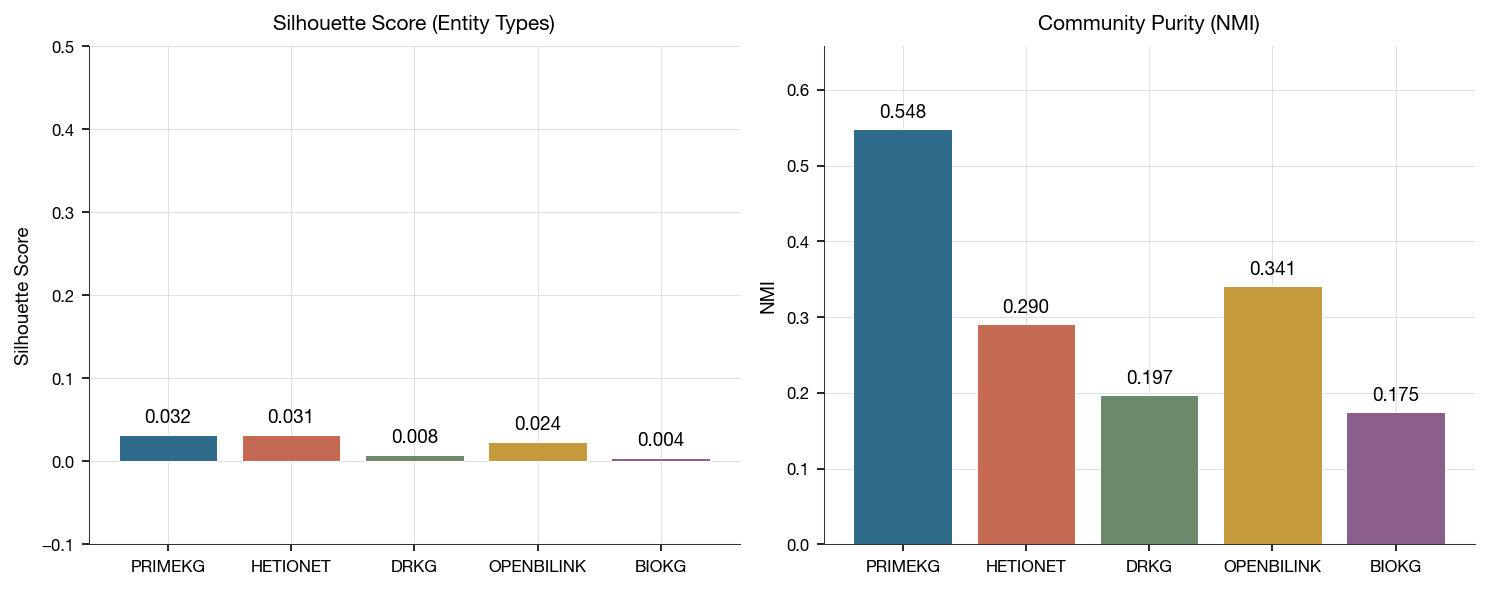

In [18]:
# Community purity - summary and plot
cp_df = pd.DataFrame([{
    'KG': name,
    'Communities': community_results[name]['n_communities'],
    'NMI': community_results[name]['nmi'],
    'ARI': community_results[name]['ari'],
    'Silhouette (entity)': community_results[name].get('silhouette_entity_type'),
    'Silhouette (Louvain)': community_results[name].get('silhouette_louvain'),
} for name in graphs])

print(cp_df.to_string(index=False))

# Plot NMI comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

kgs_plotted = cp_df['KG'].tolist()
colors = [KG_PALETTE.get(k, '#888888') for k in kgs_plotted]
x = range(len(kgs_plotted))

ax = axes[0]
sil_vals = cp_df['Silhouette (entity)'].values
bars = ax.bar(x, sil_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([k.upper() for k in kgs_plotted])
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score (Entity Types)')
ax.set_ylim(-0.1, max(0.5, max(sil_vals) * 1.2))
for bar, val in zip(bars, sil_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
nmi_vals = cp_df['NMI'].values
bars = ax.bar(x, nmi_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([k.upper() for k in kgs_plotted])
ax.set_ylabel('NMI')
ax.set_title('Community Purity (NMI)')
ax.set_ylim(0, max(0.5, max(nmi_vals) * 1.2))
for bar, val in zip(bars, nmi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'community_purity.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# Checkpoint - save scalar topology results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)


def _differential_resilience_score(ri_gold: float, ri_rand: float) -> float:
    '''Differential Resilience Score: fraction of structural headroom above
    random that is filled by biologically validated (gold-standard) edges.

    DR = (RI_gold - RI_rand) / max(eps, 1 - RI_rand)

    Range [0, 1] (negative values clipped to 0). Density-invariant: a
    larger KG with more random structure is penalised for that density.
    '''
    headroom = max(1e-6, 1.0 - ri_rand)
    return round(max(0.0, (ri_gold - ri_rand) / headroom), 4)


def _small_world_score(ratio: float) -> float:
    '''Map C/C_ER ratio to [0, 1] via log scaling.
    ratio=1 -> 0.0, ratio=10 -> 0.5, ratio=100 -> 1.0.'''
    if ratio <= 1:
        return 0.0
    return round(min(1.0, math.log(ratio) / math.log(100)), 4)


def _connectedness_score(lcc_pct: float) -> float:
    '''LCC fraction as 0-1 score.'''
    return round(lcc_pct / 100.0, 4)


# Per-KG sub-scores and raw quantification values
sub_scores = {}
raw_stats  = {}
for name in LOADED:
    # 1. Connectedness
    lcc_pct = conn_df.loc[name, 'LCC (%)'] if name in conn_df.index else 0.0
    s_conn  = _connectedness_score(lcc_pct)

    # 2. Small-world clustering
    c_emp, c_er, c_ratio = 0.0, 0.0, 1.0
    for rec in clust_df.reset_index().to_dict('records'):
        if rec['KG'] == name:
            c_emp   = rec.get('C (empirical)', 0.0)
            c_er    = rec.get('C_ER (random)', 0.0)
            c_ratio = rec.get('C / C_ER', 1.0)
            break
    s_sw = _small_world_score(c_ratio)

    # 3. Reachability (differential resilience)
    if name in diversity_results:
        ri_g    = diversity_results[name]['ri_gold']
        ri_r    = diversity_results[name]['ri_rand']
        s_reach = _differential_resilience_score(ri_g, ri_r)
    else:
        ri_g, ri_r, s_reach = float('nan'), float('nan'), 0.0

    # 4. Community purity (NMI)
    s_cp = round(community_results[name]['nmi'], 4) if name in community_results else 0.0

    sub_scores[name] = {
        'connectedness':    s_conn,
        'small_world':      s_sw,
        'reachability':     s_reach,
        'community_purity': s_cp,
    }
    raw_stats[name] = {
        'lcc_fraction':   round(lcc_pct / 100.0, 4),
        'lcc_pct':        lcc_pct,
        'C_empirical':    round(c_emp, 6),
        'C_ER_random':    round(c_er, 6),
        'C_over_CER':     round(c_ratio, 2),
        'ri_gold':        round(ri_g, 4) if not math.isnan(ri_g) else None,
        'ri_rand':        round(ri_r, 4) if not math.isnan(ri_r) else None,
        'dr_score':       s_reach,
        **({f'recovery_{h}hop': round(recovery_results[name]['recovery'][h], 4)
            for h in range(1, MAX_HOPS + 1)} if name in recovery_results else {}),
        'gold_std_pairs': recovery_results[name]['total_pairs'] if name in recovery_results else None,
        'community_nmi':  round(community_results[name]['nmi'], 4) if name in community_results else None,
        'community_ari':  round(community_results[name]['ari'], 4) if name in community_results else None,
        'n_communities':  community_results[name]['n_communities'] if name in community_results else None,
    }

# Dimension score = equal-weighted mean of 4 sub-scores
summary_scores = {
    name: round(float(np.mean(list(sub_scores[name].values()))), 4)
    for name in LOADED
}

print('Raw quantification:')
print(f'{"KG":<12s}  {"LCC %":>7s}  {"C/C_ER":>8s}  {"RI_gold":>8s}  {"RI_rand":>8s}  {"DR_score":>9s}  {"NMI":>6s}')
print('  ' + '-' * 72)
for name in LOADED:
    rs = raw_stats[name]
    print(f'{name:<12s}  {rs["lcc_pct"]:>7.2f}  {rs["C_over_CER"]:>8.1f}x  '
          f'{str(rs["ri_gold"]):>8s}  {str(rs["ri_rand"]):>8s}  '
          f'{str(rs["dr_score"]):>9s}  {str(rs["community_nmi"]):>6s}')

print(f'\nScores (0-1):')
print(f'{"KG":<12s}  {"Cohesion":>9s}  {"Sm-World":>9s}  {"Reachab.":>9s}  {"Comm-Pur":>9s}  {"Overall":>9s}')
print('  ' + '-' * 50)
for name in LOADED:
    ss = sub_scores[name]
    print(f'{name:<12s}  {ss["connectedness"]:>9.3f}  {ss["small_world"]:>9.3f}  '
          f'{ss["reachability"]:>9.3f}  {ss["community_purity"]:>9.3f}  {summary_scores[name]:>9.3f}')

ckpt = {
    'summary_scores':    summary_scores,
    'sub_scores':        sub_scores,
    'raw_stats':         raw_stats,
    'diversity_scalars': {
        name: {k: v for k, v in res.items() if k not in ('gold_curve', 'rand_curve')}
        for name, res in diversity_results.items()
    },
    'recovery_results': {
        name: {k: v for k, v in res.items() if k != 'hop_distances'}
        for name, res in recovery_results.items()
    },
    'clust_records': clust_df.reset_index().to_dict('records')
                     if not clust_df.empty else [],
    'conn_records':  conn_df.reset_index().to_dict('records')
                     if not conn_df.empty else [],
}

out = CKPT_DIR / '04_topology.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)
print(f'\nCheckpoint saved: {out}')


Raw quantification:
KG              LCC %    C/C_ER   RI_gold   RI_rand   DR_score     NMI
  ------------------------------------------------------------------------
primekg        100.00     157.3x    0.8284    0.0349     0.8222   0.548
hetionet        96.02      57.0x    0.8531     0.193      0.818  0.2903
drkg            99.16     253.8x    0.9208    0.0547     0.9162  0.1971
openbilink      99.97     608.7x    0.5106     0.002     0.5096  0.3408
biokg           93.30     373.4x    0.9001    0.0937     0.8898   0.175

Scores (0-1):
KG             Cohesion   Sm-World   Reachab.   Comm-Pur    Overall
  --------------------------------------------------
primekg           1.000      1.000      0.822      0.548      0.843
hetionet          0.960      0.878      0.818      0.290      0.737
drkg              0.992      1.000      0.916      0.197      0.776
openbilink        1.000      1.000      0.510      0.341      0.713
biokg             0.933      1.000      0.890      0.175      0.74

## Dimension Score

The topology dimension score combines four sub-metrics:

$$\text{Topology} = \frac{1}{4}\left(\text{Graph Cohesion} + \text{Clustering Coefficient} + \text{Known-Pair Recovery} + \text{Community Purity}\right)$$

---

**Graph cohesion** is the LCC fraction directly:

$$\text{Graph Cohesion}_i = \frac{|\text{LCC}_i|}{N_i} \in [0, 1]$$

---

**Clustering coefficient** maps the empirical-to-random ratio via log scaling:

$$\text{Clustering Score}_i = \min\!\left(1,\; \frac{\log(C_i / C_{\text{ER},i})}{\log 100}\right)$$

The ceiling at $C/C_{\text{ER}} = 100$ represents 100-fold enrichment over a random graph, which exceeds the practical range observed in published biomedical KGs. The log transform is appropriate because small-world enrichment scales multiplicatively. The raw $C$, $C_{\text{ER}}$, and $C/C_{\text{ER}}$ ratio are the primary reported statistics.

---

**Known-pair recovery** uses the **Differential Resilience Score**, a density-invariant measure of how much better the KG preserves externally validated drug-disease pairs under random edge dropout compared with random pairs:

$$\text{Recovery Score}_i = \frac{\text{RI}_{\text{gold},i} - \text{RI}_{\text{rand},i}}{\max\!(\varepsilon,\; 1 - \text{RI}_{\text{rand},i})}$$

where $\text{RI}$ is the **Resilience Index** (normalised area under the 2-hop recovery curve across dropout rates $r \in \{0, 0.1, 0.2, 0.3, 0.4, 0.5\}$):

$$\text{RI} = \frac{\int_0^{0.5} \text{Recovery}(r)\, dr}{0.5}$$

The numerator $(\text{RI}_{\text{gold}} - \text{RI}_{\text{rand}})$ captures the raw gap in structural resilience between validated and random pairs. The denominator $(1 - \text{RI}_{\text{rand}})$ normalises for graph density: a denser KG that keeps random pairs well-connected is penalised, ensuring the score rewards *specificity* of gold-standard connectivity rather than bulk edge redundancy. A score of 0 indicates no preferential preservation; 1 indicates that gold-standard pairs are perfectly preserved while random pairs are fully disrupted. The gold standard is Open Targets approved drug indications, external to all three KGs.

---

**Community purity** is the Normalized Mutual Information (NMI) between Louvain community assignments and entity type labels:

$$\text{Community Purity}_i = \text{NMI}(\text{Louvain communities}, \text{entity types}) \in [0, 1]$$

NMI = 0 indicates that structural communities are independent of entity types; NMI = 1 indicates perfect correspondence. Silhouette scores (sampled at 20,000 nodes using Jaccard distance) are reported as a supplementary robustness check.
